# Giai đoạn 7: Bổ sung Đặc trưng Phi tuyến tính (Non-linear Features)
Bổ sung các đặc trưng chuẩn y khoa bao gồm **Poincaré Plot (SD1, SD2)** và **Sample Entropy (SampEn)** để đo lường mức độ hỗn loạn (chaos) của nhịp tim, giúp phát hiện AFib chính xác hơn.
Đồng thời, chúng ta sẽ gỡ bỏ luật lọc SQI quá khắt khe ở biên độ đỉnh (bước đã làm giảm Accuracy ở file 06) để giữ lại các ca AFib phức tạp.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks, butter, filtfilt, welch
from scipy.interpolate import interp1d
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import lightgbm as lgb
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

### 1. Khai báo các hàm trích xuất đặc trưng (Bao gồm Non-linear)

In [2]:
def butter_bandpass_filter(data, lowcut=0.5, highcut=8.0, fs=125.0, order=3):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

def calculate_time_domain(rr_intervals):
    if len(rr_intervals) < 2: return {k: np.nan for k in ['Mean_NN', 'SDNN', 'RMSSD', 'pNN50', 'NN50', 'CV']}
    mean_nn = np.mean(rr_intervals)
    sdnn = np.std(rr_intervals, ddof=1)
    diff_nn = np.diff(rr_intervals)
    rmssd = np.sqrt(np.mean(diff_nn**2))
    nn50 = np.sum(np.abs(diff_nn) > 50)
    pnn50 = (nn50 / len(diff_nn)) * 100 if len(diff_nn) > 0 else 0
    cv = (sdnn / mean_nn) * 100 if mean_nn > 0 else np.nan
    return {'Mean_NN': mean_nn, 'SDNN': sdnn, 'RMSSD': rmssd, 'pNN50': pnn50, 'NN50': nn50, 'CV': cv}

def calculate_frequency_domain(rr_intervals, fs_interp=4.0):
    nan_result = {k: np.nan for k in ['LF', 'HF', 'LF_HF_Ratio', 'LF_norm', 'HF_norm', 'Total_Power']}
    if len(rr_intervals) < 10: return nan_result
    t = np.cumsum(rr_intervals) / 1000.0
    t -= t[0]
    rr_sec = rr_intervals / 1000.0
    try:
        f_interp = interp1d(t, rr_sec, kind='cubic')
        t_interp = np.arange(t[0], t[-1], 1.0 / fs_interp)
        rr_interp = f_interp(t_interp)
    except: return nan_result
    nperseg = min(256, len(rr_interp))
    if nperseg < 2: return nan_result
    f, pxx = welch(rr_interp, fs=fs_interp, nperseg=nperseg)
    lf_band = (f >= 0.04) & (f <= 0.15)
    hf_band = (f >= 0.15) & (f <= 0.4)
    df = f[1] - f[0]
    lf = np.sum(pxx[lf_band]) * df
    hf = np.sum(pxx[hf_band]) * df
    total_power = lf + hf
    lf_hf_ratio = lf / hf if hf > 0 else np.nan
    return {'LF': lf, 'HF': hf, 'LF_HF_Ratio': lf_hf_ratio, 'LF_norm': (lf/total_power)*100 if total_power>0 else np.nan, 'HF_norm': (hf/total_power)*100 if total_power>0 else np.nan, 'Total_Power': total_power}

# -------------------- ĐẶC TRƯNG MỚI (NON-LINEAR) --------------------
def calculate_nonlinear_domain(rr_intervals):
    nan_result = {'SD1': np.nan, 'SD2': np.nan, 'SampEn': np.nan}
    if len(rr_intervals) < 10: return nan_result
    
    # 1. Poincaré Plot (SD1, SD2)
    rr_n = rr_intervals[:-1]
    rr_n1 = rr_intervals[1:]
    sd1 = np.sqrt(np.var(rr_n - rr_n1) / 2.0)
    sd2 = np.sqrt(np.var(rr_n + rr_n1) / 2.0)
    
    # 2. Sample Entropy (m=2, r=0.2 * SDNN)
    N = len(rr_intervals)
    m = 2
    r = 0.2 * np.std(rr_intervals)
    
    def _sampen():
        if r == 0: return np.nan
        B = 0; A = 0
        for i in range(N - m):
            for j in range(i + 1, N - m):
                if np.max(np.abs(rr_intervals[i:i+m] - rr_intervals[j:j+m])) <= r:
                    B += 1
                    if np.abs(rr_intervals[i+m] - rr_intervals[j+m]) <= r:
                        A += 1
        if B == 0 or A == 0: return 2.0 # Giá trị entropy max fallback
        return -np.log(A / B)
        
    return {'SD1': sd1, 'SD2': sd2, 'SampEn': _sampen()}
# --------------------------------------------------------------------

def extract_features_with_sqi_and_nonlinear(time_array, ppg_array, fs=125.0):
    if np.std(ppg_array) < 1e-4:
        return None, "Mất tín hiệu (Flatline)"
        
    clean_ppg = butter_bandpass_filter(ppg_array, fs=fs)
    min_distance = int(0.25 * fs)
    peaks, _ = find_peaks(clean_ppg, distance=min_distance, prominence=np.std(clean_ppg)*0.5)
    
    if len(peaks) < 15:
        return None, "Nhịp quá chậm hoặc mất tín hiệu"
    if len(peaks) > 110:
        return None, "Nhiễu rung hoặc nhịp quá nhanh vô lý"
        
    # Đã LOẠI BỎ bộ lọc CV biên độ đỉnh quá khắt khe ở file 06 để cứu các ca AFib thật sự bị gạt nhầm.
    # peak_amps = clean_ppg[peaks]
    # if np.std(peak_amps) / (np.mean(peak_amps) + 1e-6) > 1.5: ...
        
    peak_times = time_array[peaks]
    rr_intervals = np.diff(peak_times) * 1000.0
    valid_rr = rr_intervals[(rr_intervals >= 300) & (rr_intervals <= 2000)]
    if len(valid_rr) < 10:
        return None, "Quá ít nhịp R-R hợp lệ"
        
    features = {'HR_mean': 60000.0 / np.mean(valid_rr)}
    features.update(calculate_time_domain(valid_rr))
    features.update(calculate_frequency_domain(valid_rr))
    features.update(calculate_nonlinear_domain(valid_rr)) # THÊM NON-LINEAR FEATURES
    
    for k, v in features.items():
        if np.isnan(v): features[k] = 0.0
            
    return features, "Thành công"

### 2. Trích xuất dữ liệu từ Raw Signal

In [3]:
raw_data_path = '../../data/train/ppg_af_train.csv'
print("Đang đọc dữ liệu sóng thô...")
df_raw = pd.read_csv(raw_data_path)

FS = 125.0
WINDOW_SIZE_SEC = 30
window_size_samples = int(WINDOW_SIZE_SEC * FS)
total_samples = len(df_raw)

features_list = []
sqi_rejection_stats = {}

print("Bắt đầu trích xuất đặc trưng có kết hợp Non-linear & SQI...")
for start_idx in range(0, total_samples, window_size_samples):
    end_idx = start_idx + window_size_samples
    if end_idx > total_samples: break
        
    window = df_raw.iloc[start_idx:end_idx]
    label = 1 if np.mean(window['status'].values) > 0.5 else 0
    
    time_arr = window['time'].values
    ppg_arr = window['ppg'].values
    
    feats, status_msg = extract_features_with_sqi_and_nonlinear(time_arr, ppg_arr, fs=FS)
    
    if feats is not None:
        feats['status'] = label
        features_list.append(feats)
    else:
        sqi_rejection_stats[status_msg] = sqi_rejection_stats.get(status_msg, 0) + 1

df_advanced = pd.DataFrame(features_list)
print(f"\n🎉 Đã trích xuất thành công {len(df_advanced)} cửa sổ.")

os.makedirs('../../data/features', exist_ok=True)
df_advanced.to_csv('../../data/features/mimic_train_features_advanced.csv', index=False)
print("Đã lưu tập dữ liệu cao cấp vào: data/features/mimic_train_features_advanced.csv")

Đang đọc dữ liệu sóng thô...
Bắt đầu trích xuất đặc trưng có kết hợp Non-linear & SQI...

🎉 Đã trích xuất thành công 1202 cửa sổ.
Đã lưu tập dữ liệu cao cấp vào: data/features/mimic_train_features_advanced.csv


### 3. Huấn luyện LightGBM và xem sức mạnh của Non-linear Features

Đang Tuning LightGBM trên tập dữ liệu Non-linear...

KẾT QUẢ CUỐI CÙNG: DỮ LIỆU SẠCH + ĐẶC TRƯNG PHI TUYẾN (NON-LINEAR)
🎯 Accuracy  : 0.9627
🎯 Precision : 0.9440
🎯 Recall    : 0.9833
🎯 F1-Score  : 0.9633


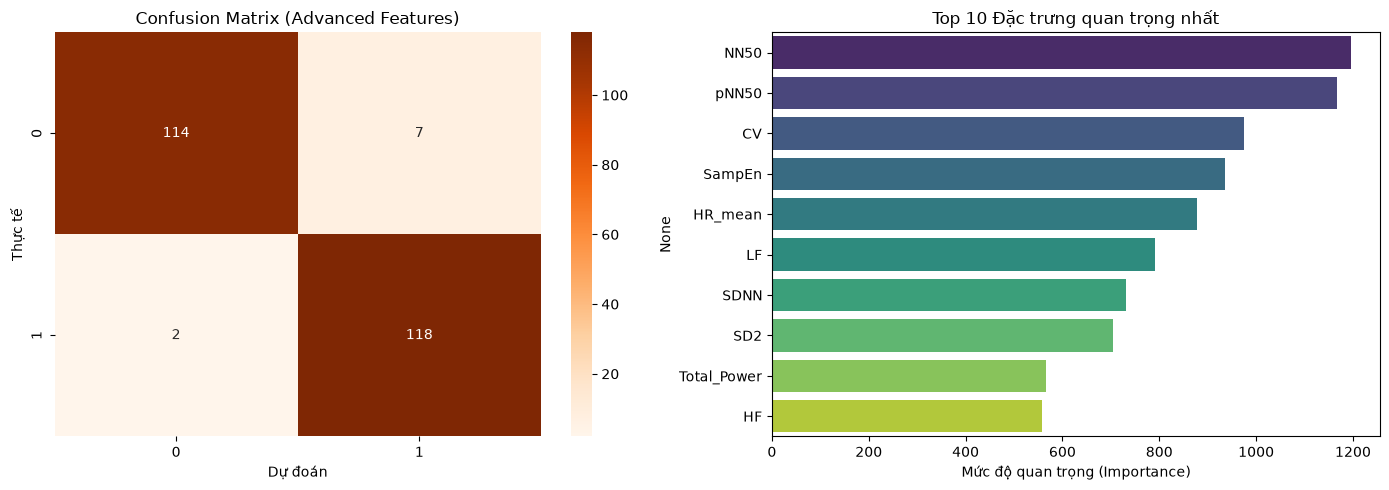


Đã lưu mô hình tại: models/compare/mimic_lightgbm_advanced_nonlinear.pkl


In [4]:
X = df_advanced.drop(columns=['status'])
y = df_advanced['status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

lgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', lgb.LGBMClassifier(random_state=42, verbose=-1))
])

param_grid = {
    'classifier__n_estimators': [300, 500],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__num_leaves': [31, 50]
}

print("Đang Tuning LightGBM trên tập dữ liệu Non-linear...")
grid_search = GridSearchCV(estimator=lgb_pipeline, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_lgb = grid_search.best_estimator_
y_pred = best_lgb.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n" + "="*50)
print("KẾT QUẢ CUỐI CÙNG: DỮ LIỆU SẠCH + ĐẶC TRƯNG PHI TUYẾN (NON-LINEAR)")
print("="*50)
print(f"🎯 Accuracy  : {acc:.4f}")
print(f"🎯 Precision : {prec:.4f}")
print(f"🎯 Recall    : {rec:.4f}")
print(f"🎯 F1-Score  : {f1:.4f}")
print("="*50)

# Trực quan hoá Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix (Advanced Features)')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')

# Hiển thị Top 10 Feature Importances
plt.subplot(1, 2, 2)
lgb_model = best_lgb.named_steps['classifier']
importances = lgb_model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False).head(10)
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="viridis")
plt.title("Top 10 Đặc trưng quan trọng nhất")
plt.xlabel("Mức độ quan trọng (Importance)")

plt.tight_layout()
plt.show()

# Lưu mô hình cuối cùng
joblib.dump(best_lgb, '../../models/compare/mimic_lightgbm_advanced_nonlinear.pkl')
print("\nĐã lưu mô hình tại: models/compare/mimic_lightgbm_advanced_nonlinear.pkl")